### Avaliando a Correlação com a Variável Alvo - Preço Boi Gordo

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.options.mode.copy_on_write = True

In [23]:
import seaborn as sns

def plot_corr_target(df, target, save_path = None):

    def corr_range(corr):
        if np.abs(corr) > 0.2 and corr < 0.9:
            return corr
            
    df = df.drop(columns=['data'])

    correlations = df.corr()[target].drop(target).apply(corr_range)

    correlations = correlations.dropna()

    cols_range = correlations.index

    colors = sns.diverging_palette(10, 130, as_cmap = True)
    
    color_mapped = correlations.map(colors)

    sns.set_style("darkgrid", {"axes.facecolor": "#eaeaf2", "grid.linewidth": 1.5})

    fig = plt.figure(figsize = (12, 8))

    plt.barh(correlations.index, correlations.values, color = color_mapped)

    # Define o título e os rótulos dos eixos do gráfico
    plt.title("Correlação com boi real", fontsize = 16)
    plt.xlabel("Coeficiente de Correlação", fontsize = 14)
    plt.ylabel("Variável", fontsize = 14)
    plt.xticks(fontsize = 12)
    plt.yticks(fontsize = 12)
    plt.grid(axis="x")

    # Ajusta o layout para evitar sobreposição
    plt.tight_layout()

    # Salva o gráfico como um arquivo PNG, se um caminho for fornecido
    if save_path:
        plt.savefig(save_path, format = "png", dpi = 600)

    # Fecha a figura para liberar memória
    plt.close(fig)

    # Retorna a figura criada
    return fig, cols_range

In [9]:
df_agro = pd.read_csv('df_agro.csv')
df_agro = df_agro.drop('Unnamed: 0', axis=1)
df_agro.columns

Index(['data', 'CovidPeriodFlag', 'tarifa_base_carne',
       'tarifa_adicional_trump', 'tarifas_carne_total', 'Year', 'Month',
       'DayOfWeek', 'ano_novo_flag', 'carnaval_core_flag',
       'carnaval_window_flag', 'pascoa_flag', 'pascoa_window_flag',
       'dias_maes_flag', 'dias_maes_weekend_flag', 'festas_juninas_flag',
       'santo_antonio_flag', 'sao_joao_flag', 'sao_pedro_flag',
       'ferias_midyear_flag', 'ferias_verao_flag', 'dias_pais_flag',
       'dias_pais_weekend_flag', 'independencia_flag',
       'independencia_window_flag', 'dia_criancas_flag', 'finados_flag',
       'finados_weekend_flag', 'natal_flag', 'natal_window_flag',
       'fim_ano_window_flag', 'sazonal_carne_weight', 'scpdsi_goias',
       'precip_total_mm', 'TEMPERATURA', 'ipca', 'selic', 'PIB', 'PIB_Agro',
       'cme_valor', 'cme_Vol.', 'boi_futuro', 'boi_futuro_Vol.', 'boi_real',
       'boi_dolar', 'soja_real', 'soja_dolar', 'soja_futuro', 'soja_Vol.',
       'milho_futuro', 'milho_Vol.', 'milho_r

In [10]:
grafico1, cols = plot_corr_target(df_agro, "boi_real")
cols = cols.to_list()
print(cols)

['CovidPeriodFlag', 'TEMPERATURA', 'ipca', 'selic', 'PIB', 'cme_valor', 'soja_real', 'soja_dolar', 'soja_futuro', 'milho_futuro', 'milho_real', 'milho_dolar', 'taxa', 'el_nino_encoded']


In [11]:
df_selected_feat = df_agro[cols]
df_selected_feat.insert(0, 'data', df_agro['data'])
df_selected_feat.insert(1, 'boi_real', df_agro['boi_real'])
df_selected_feat.insert(2, 'boi_dolar', df_agro['boi_dolar'])
df_selected_feat.head()

,data,boi_real,boi_dolar,CovidPeriodFlag,TEMPERATURA,ipca,selic,PIB,cme_valor,soja_real,soja_dolar,soja_futuro,milho_futuro,milho_real,milho_dolar,taxa,el_nino_encoded
0,2020-01-02,192.95,47.96,0,28.33,4.19,4.4,0.41,201.85,88.08,21.89,956.25,391.50,48.43,12.04,4.0260,0
1,2020-01-03,196.70,48.53,0,26.00,4.19,4.4,0.41,204.55,88.91,21.94,941.50,386.50,48.91,12.07,4.0669,0
2,2020-01-04,196.70,48.53,0,25.95,4.19,4.4,0.41,204.55,88.91,21.94,941.50,386.50,48.91,12.07,4.0669,0
3,2020-01-05,196.70,48.53,0,28.10,4.19,4.4,0.41,204.55,88.91,21.94,941.50,386.50,48.91,12.07,4.0669,0
4,2020-01-06,196.40,48.24,0,27.04,4.19,4.4,0.41,205.39,88.24,21.68,944.75,384.75,48.99,12.03,4.0616,0


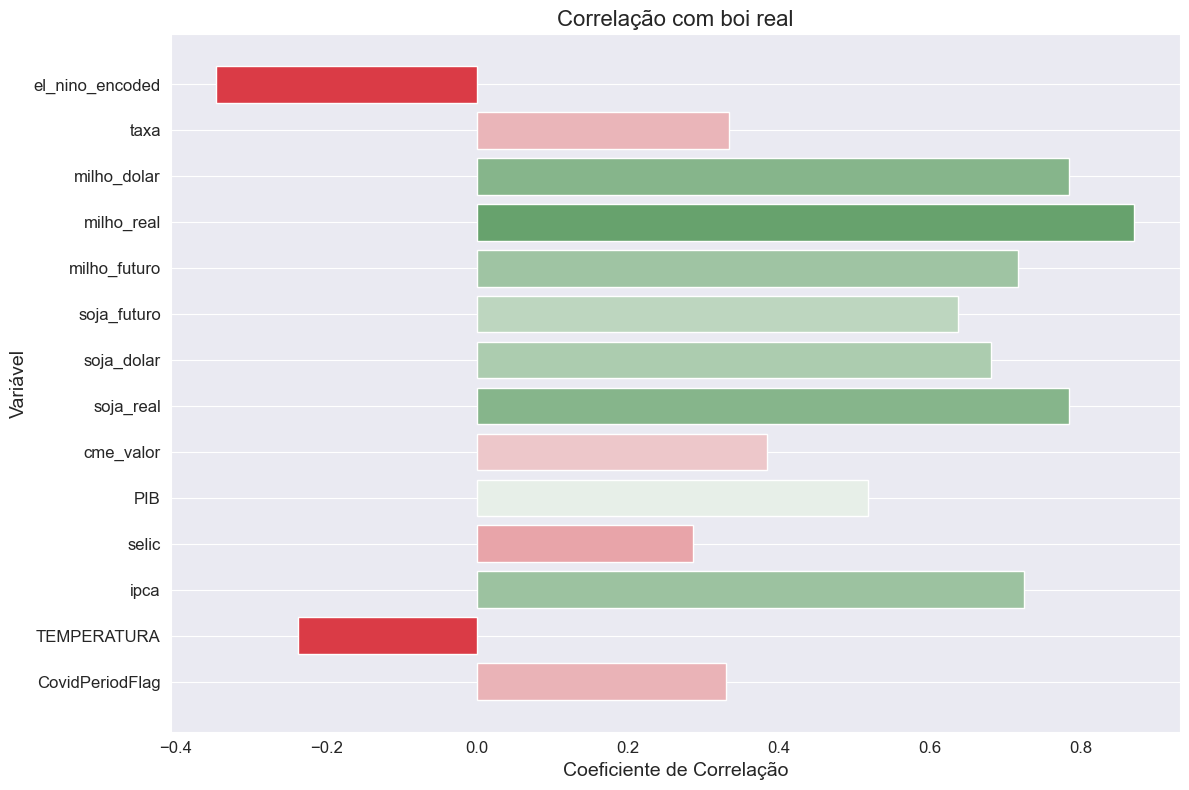

In [12]:
grafico1

In [13]:
df_selected_feat.to_csv('df_selected.csv')

### Realizando os mesmo processo com o DataFrame Normalizado

In [31]:
df_norm = pd.read_csv('df_normalized.csv')
df_norm.head()

,data,CovidPeriodFlag,ano_novo_flag,carnaval_core_flag,carnaval_window_flag,pascoa_flag,pascoa_window_flag,dias_maes_flag,dias_maes_weekend_flag,festas_juninas_flag,...,milho_Vol.,milho_real,milho_dolar,taxa,ciclo_MENOR_TX_NASC,ciclo_NASC_COMPLEMENTARES,ciclo_PICO_NASCIMENTOS,aspecto_PLANEJAMENTO,aspecto_SAFRA,el_nino_encoded
0,2020-01-02,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.406033,0.575179,0.641516,0.000000,0,0,1,1,0,0.5
1,2020-01-03,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.455546,0.575179,0.641516,0.011745,0,0,1,1,0,0.5
2,2020-01-04,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.455546,0.540149,0.628997,0.011745,0,0,1,1,0,0.5
3,2020-01-05,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.455546,0.540149,0.628997,0.011745,0,0,1,1,0,0.5
4,2020-01-06,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.424853,0.545706,0.612785,0.010212,0,0,1,1,0,0.5


In [27]:
grafico2, cols = plot_corr_target(df_norm, "boi_real")
print(cols)

Index(['CovidPeriodFlag', 'PIB_Agro', 'taxa'], dtype='object')


In [28]:
df_norm_selected_feat = df_norm[cols]
df_norm_selected_feat.insert(0, 'data', df_agro['data'])
df_norm_selected_feat.insert(1, 'boi_real', df_agro['boi_real'])
df_norm_selected_feat.insert(2, 'boi_dolar', df_agro['boi_dolar'])
df_norm_selected_feat.head()

,data,boi_real,boi_dolar,CovidPeriodFlag,PIB_Agro,taxa
0,2020-01-02,192.95,47.96,0,0.278479,0.000000
1,2020-01-03,196.70,48.53,0,0.278479,0.011745
2,2020-01-04,196.70,48.53,0,0.278479,0.011745
3,2020-01-05,196.70,48.53,0,0.278479,0.011745
4,2020-01-06,196.40,48.24,0,0.278479,0.010212


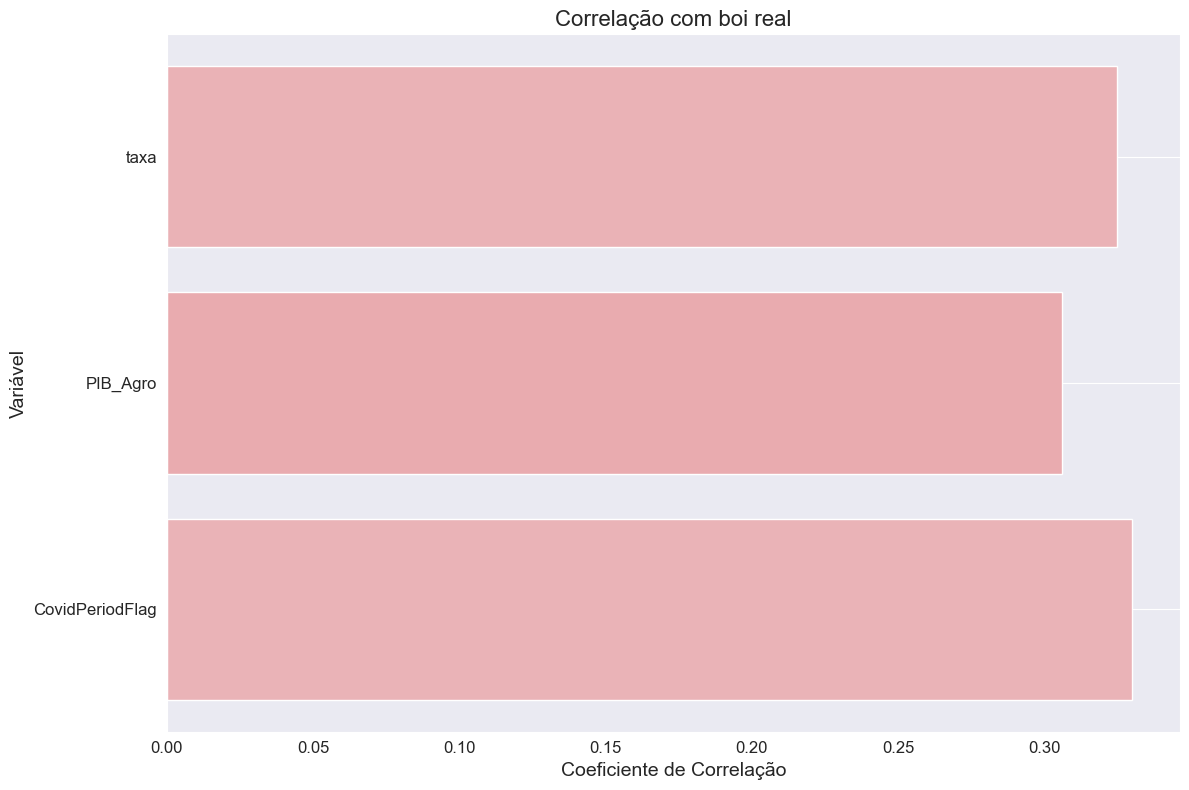

In [29]:
grafico2

In [30]:
df_norm_selected_feat.to_csv('df_norm_selected.csv')